In [1]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
def load_nc(file_path):
    ds = nc.Dataset(file_path)
    
    print("Variables:", ds.variables.keys())
    
    # change 'methane' based on dataset
    data = ds.variables[list(ds.variables.keys())[0]][:]
    
    return data

In [3]:
def normalize(data):
    data = np.array(data)
    data = (data - np.min(data)) / (np.max(data) - np.min(data))
    return data

In [4]:
def add_gaussian_noise(image, mean=0, std=0.2):
    noise = np.random.normal(mean, std, image.shape)
    noisy = image + noise
    noisy = np.clip(noisy, 0, 1)
    return noisy

In [5]:
def denoise_image(image):
    img = (image * 255).astype(np.uint8)
    
    # Gaussian Blur
    clean = cv2.GaussianBlur(img, (5, 5), 0)
    
    # back to float
    clean = clean / 255.0
    
    return clean

In [6]:
def detect_methane(image, threshold=0.6):
    # simple threshold-based segmentation
    mask = image > threshold
    return mask

In [7]:
def show_images(original, noisy, clean, mask):
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.title("Original")
    plt.imshow(original, cmap='viridis')

    plt.subplot(2, 2, 2)
    plt.title("Noisy (Twist)")
    plt.imshow(noisy, cmap='viridis')

    plt.subplot(2, 2, 3)
    plt.title("Denoised")
    plt.imshow(clean, cmap='viridis')

    plt.subplot(2, 2, 4)
    plt.title("Methane Detection")
    plt.imshow(mask, cmap='gray')

    plt.tight_layout()
    plt.show()

Available variables: dict_keys(['scanline', 'ground_pixel', 'time', 'corner', 'layer', 'level', 'delta_time', 'time_utc', 'qa_value', 'latitude', 'longitude', 'methane_mixing_ratio', 'methane_mixing_ratio_precision', 'methane_mixing_ratio_bias_corrected', 'methane_mixing_ratio_bias_corrected_destriped'])


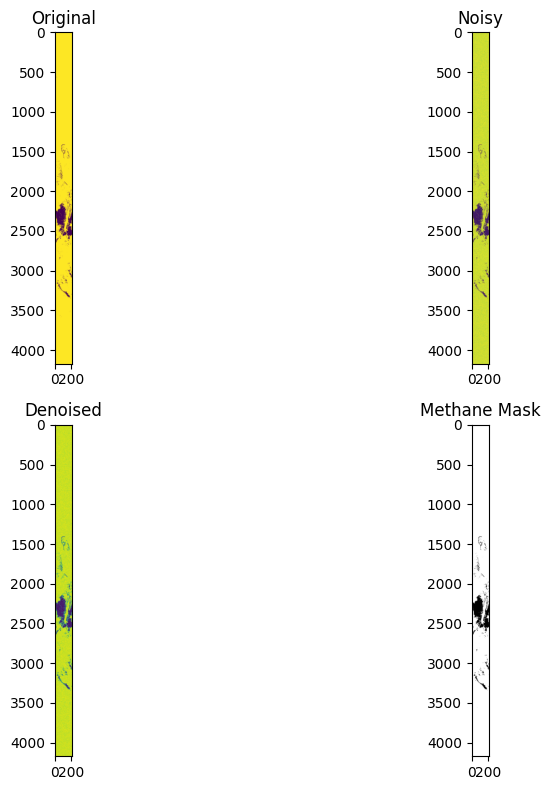

In [13]:
import netCDF4 as nc
import numpy as np
import cv2
import matplotlib.pyplot as plt

file_path = "pipeline/dataset/S5P_OFFL_L2__CH4____20260331T100721_20260331T114851_43854_03_020901_20260402T023239 (1).nc"


# ✅ Step 1: Load .nc
def load_nc(file_path):
    ds = nc.Dataset(file_path)

    product = ds.groups["PRODUCT"]

    print("Available variables:", product.variables.keys())

    data = product.variables["methane_mixing_ratio_bias_corrected"][:]

    # remove extra dimensions if present
    data = np.squeeze(data)

    return data


# ✅ Step 2: Normalize
def normalize(data):
    data = np.array(data)
    data = (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-8)
    return data


# ✅ Step 3: Add Noise
def add_gaussian_noise(image, mean=0, std=0.2):
    noise = np.random.normal(mean, std, image.shape)
    noisy = image + noise
    return np.clip(noisy, 0, 1)


# ✅ Step 4: Denoise
def denoise_image(image):
    img = (image * 255).astype(np.uint8)
    clean = cv2.GaussianBlur(img, (5, 5), 0)
    return clean / 255.0


# ✅ Step 5: Detect Methane (simple threshold)
def detect_methane(image, threshold=0.6):
    return image > threshold


# ✅ Step 6: Visualization
def show_images(original, noisy, clean, mask):
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.title("Original")
    plt.imshow(original, cmap="viridis")

    plt.subplot(2, 2, 2)
    plt.title("Noisy")
    plt.imshow(noisy, cmap="viridis")

    plt.subplot(2, 2, 3)
    plt.title("Denoised")
    plt.imshow(clean, cmap="viridis")

    plt.subplot(2, 2, 4)
    plt.title("Methane Mask")
    plt.imshow(mask, cmap="gray")

    plt.tight_layout()
    plt.show()


# 🚀 RUN PIPELINE (IMPORTANT FIX)
raw = load_nc(file_path)   # ✅ yahi missing tha

norm = normalize(raw)

noisy = add_gaussian_noise(norm)

clean = denoise_image(noisy)

mask = detect_methane(clean)

show_images(norm, noisy, clean, mask)